---
title: "Relaxation, Newton, Secant"
subtitle: "Lecture 5: Chapter 2: Solving nonlinear equations in 1d II"
code-fold: true
format:
  html: default
  pdf: default
---

{{< include ../extras/_lecture-header.html >}}

::: {.callout-note}

This chapter will be mainly based on Chapter 1 of An Introduction to Numerical Analysis by @Suli. These notes are mainly a record of what we discussed and are not a substitute for attending the lectures and reading books! If anything is unclear/wrong, let me know and I will update the notes.
 
:::


In [1]:
# | code-fold: true

using Plots, LaTeXStrings, Polynomials, Printf

function simple_iteration(g, x1; N=100, tol=1e-10, flag=false)
    x = Vector{Float64}(undef, N)
    x[1] = x1
    
    for n ∈ 2:N
        x[n] = g(x[n-1])
        
        if !isfinite(x[n])
            return x[1:n], false 
        end

        # compute relative error
        rel_err = abs(x[n] - x[n-1]) / max(abs(x[n]), 1e-12)
        
        if rel_err < tol
            return x[1:n], true 
        end
    end
    
    if flag
        @warn "Fixed-point iteration did not converge within $N iterations."
    end
    return x, false
end

function orderOfConvergence(x, ξ; α=0)
    err = @. abs(x - ξ)
    logerr = @. log10(err)
    ratios = [NaN; [logerr[i+1] / logerr[i] for i in 1:length(logerr)-1]]
    if (α == 0)
        α = ratios[end]
        αr = round(α, sigdigits=3)
    end
    mu = [NaN; [err[i+1] / err[i]^α for i in 1:length(err)-1]]

    @printf("%-10s %-16s %-12s %-10s %-14s\n",
        "iteration", "abs error", "log error", "α", "μ (α=$(round(α, sigdigits=3)))")
    for i in 1:length(x)
        @printf("%-10d %-16.6e %-12.4f %-10.4f %-14.4f\n",
            i, err[i], logerr[i], ratios[i], mu[i])
    end
end

function μ( x, ξ; α=1 )
    return @. abs( x[2:end] - ξ ) / ( abs(x[1:end-1] - ξ )^α );
end 

μ (generic function with 1 method)

* Quiz 1

## Previously....

* Considered the simple iteration $x_{n+1} = g(x_n)$, 
* Lemma: if simple iteration converges, then it converges to a fixed point,
* Example: $g(x) = \log(2x+1)$ on $[1,2]$ and saw that the simple iteration converged to $\xi \approx 1.26$,
* Example: $h(x) = \frac{e^x-1}{2}$ converged to $0$, 
* We saw (numerically) that $x_{n+1} = g(x_n)$ converges linearly, 
* Defined: contraction; showed it $|g'| \leq L < 1$ then $g$ is a contraction,   
* Contraction mapping theorem: if $g: [a,b]\to[a,b]$ is a contraction then there exists a unique fixed point $\xi = g(\xi) \in [a,b]$. Moreover, the iteration $x_{n+1} = g(x_n)$ converges to $\xi$ at least linearly with asymptotic error constant $\mu := |g'(\xi)|$.  
* We showed that $g(x) = \log(2x+1)$ is a contraction with constant $L=\tfrac23$.

::: {#exr-simple-no-its}

[](../exercises/bank.html#bank-exr-simple-no-its)

Suppose $g : [a,b] \to [a,b]$ is a contraction with constant $L < 1$ and consider the simple iteration $x_{n+1} = g(x_n)$. Let $\xi \in [a,b]$ be the unique fixed point of $g$ in $[a,b]$. 

1. Show that $|x_1 - \xi| \leq \frac1{1-L} |x_1 - x_2|$, 
2. Hence, write down a lower bound on the number of iterations $n$ to ensure $|x_{n+1} - \xi|\leq \varepsilon$.

::: {.exercise-hint style="display: none"}

1. Use the triangle inequaltiy, 
2. Use the fact that 

\begin{align}
    |x_{n+1} - \xi| \leq \frac{L^n}{1-L} |x_1 - x_2|
\end{align}

:::

::: {.exercise-solution style="display: none"}

Recall that $|x_{n+1} - \xi| \leq L |x_{n} - \xi|$. In particular, we have $|x_1 - \xi| \leq |x_1 - x_2| + |x_2 - \xi| \leq |x_1 - x_2| + L|x_1-\xi|$ and thus $|x_1 - \xi| \leq \frac1{1-L} |x_1 - x_2|$. As a result, we have 

\begin{align}
    |x_{n+1} - \xi| &\leq L^n |x_1 - \xi| \nonumber\\
                    &\leq 
                    \frac
                        {L^n}
                        {1-L} 
                    |x_1 - x_2|
\end{align}

This number is less than $\epsilon$ when

\begin{align}
    n \geq \frac{ \log \frac{|x_1-x_2|}{\epsilon(1-L)}  }{\log\frac1L}.
\end{align}

This gives an upper bound on the number of iterations needed in order to be within some fixed tolerance.

Let's back to the function $g(x) = \log(2x+1)$. For an error of $\epsilon = 10^{-10}$, we require around $54$ iterations. Actually, $40$ will do (but we have an upper bound): 

In [2]:
g(x) = log( 2x + 1 )
x, _ = simple_iteration( g, 1.0; N=1000, tol=0.0 )    # fixed point ξ ≈ 1.256 
ξ = x[end]

ϵ = 1e-10; 
L = 2/3;
x1 = 1; x2 = g(x1);
@show N = log( abs(x1-x2) / ( ϵ * (1-L) ) ) / log( 1/L )

x, _ = simple_iteration( g, 1.0; N=54, tol=1e-20 )

abs( x[40] - ξ )

N = log(abs(x1 - x2) / (ϵ * (1 - L))) / log(1 / L) = 53.78490871074893


8.923461969345681e-11

:::

:::

::: {#def-stable}

$\xi$ is a *stable fixed point of $g$* if the iteration $x_{n+1} = g(x_n)$ converges to $\xi$ for all $x_1$ sufficiently close to $\xi$.  
$\xi$ is an *unstable fixed point of $g$* if for all $\delta > 0$ there exists $x_1 \in [\xi-\delta, \xi+\delta]$ for which $x_{n+1} = g(x_n)$ does not converge to $\xi$.

:::

::: {#exm-change-sign-10}

We have seen that $\xi = 1.26...$ is a stable fixed point of $g(x) = \log( 2x + 1 )$ and we saw (numerically) that $\xi \approx 1.26...$ is an unstable fixed point of $h(x) = \frac{e^x-1}{2}$.

:::

::: {#thm-unstable}

Suppose $h'$ is continuous with $|h'(x)| > L >  1$ for all $x \in I$ where $I$ is an interval containing $\xi = h(\xi)$. For $x_{1}\in I \setminus \{\xi\}$, define $x_{n+1} = h(x_n)$. Then, there exists $N$ such that $x_N \not\in I$. 

:::

**Proof.** Let $I = [\xi-\delta,\xi+\delta]$ be such that $|h'| > L$ on $I$. If $x_n \in I$ then there exists $\eta \in I$ such that

\begin{align}
    |x_{n+1} - \xi| &= |h(x_{n}) - h(\xi)| \nonumber\\
    %
    &=  |h'(\eta)| |x_n - \xi| \nonumber\\
    %
    &> L |x_{n} - \xi|.
\end{align}

Similarly, if $x_{n+1} \in I$, then $|x_{n+2} - \xi| > L^2|x_{n} - \xi|$. Since $L> 1$ (and so $L^n\to\infty$ as $n\to\infty$), there exists $N$ such that $x_{n+N} \not\in I$. 

If one can additionally prove that no $x\not\in I$ maps to $\xi$, then the sequence $(x_n)$ does not converge to $\xi$.

::: {#exm-h-unstable}

$\xi = 1.26...$ is an unstable fixed point of $h(x) = \frac{e^x -1}{2}$. In fact, for $x_1 > \xi$, $x_{n+1}= h(x_n)$ diverges to infinity.  

$\zeta = 0$ is a stable fixed point of $h$. For $x_1 < \xi$, $x_{n+1}= h(x_n)$ converges to $0$. 

:::

## Relaxation

* Recall that we have $f:[a,b]\to\mathbb R$ and we want to find roots $\xi$ (i.e. such that $f(\xi)=0$),
* Define $x_{n+1} = x_{n} - \lambda f(x_{n})$ 

In [3]:
function relaxation( f, λ, x1; N=100, tol=1e-10)
    x = [x1]
    r = 0.;
    for n ∈ 2:N
        push!( x, x[n-1] - λ*f(x[n-1]) )
        r = abs(f(x[end]));
        if (r < tol)
            return x
        end
    end
    @warn "max interations with |f| = $r";
    return x
end

relaxation (generic function with 1 method)

::: {#exm-Kepler}
# Kepler's equation

Consider Kepler's equation: 

\begin{align*}
    &f(\psi) = \psi - \epsilon \sin \psi - 2\pi
\end{align*}

:::

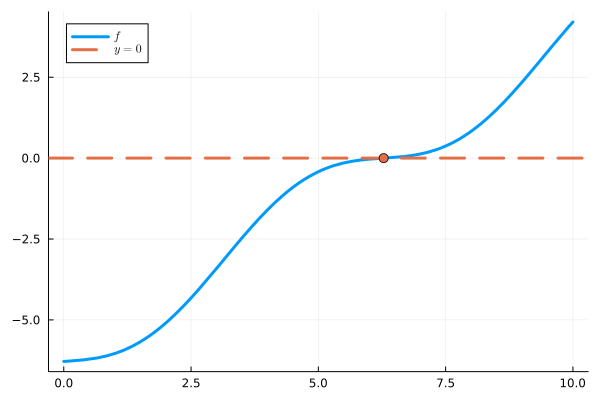

In [4]:
# Kepler's equation with t = τ = 1 
ϵ = 0.9;

f(ψ) = ψ - ϵ * sin(ψ) - 2π; 
f′(ψ) = 1 - ϵ * cos(ψ);
f′′(ψ) = ϵ * sin(ψ);

# f has a zero at 2π
ξ = 2π;

plot( f, 0, 10; label=L"f", lw=3 )
hline!( [0] , linestyle=:dash, lw = 3, label=L"y=0")
scatter!( [ξ], [f(ξ)], markersize=5, primary=false )

┌ Warning: max interations with |f| = 0.0012486749578126677
└ @ Main In[3]:11
[ Info: Saved animation to c:\Users\jack6\Math5485-Fall-2026\Math5485\images\Relaxed.gif


Plots.AnimatedGif("c:\\Users\\jack6\\Math5485-Fall-2026\\Math5485\\images\\Relaxed.gif")
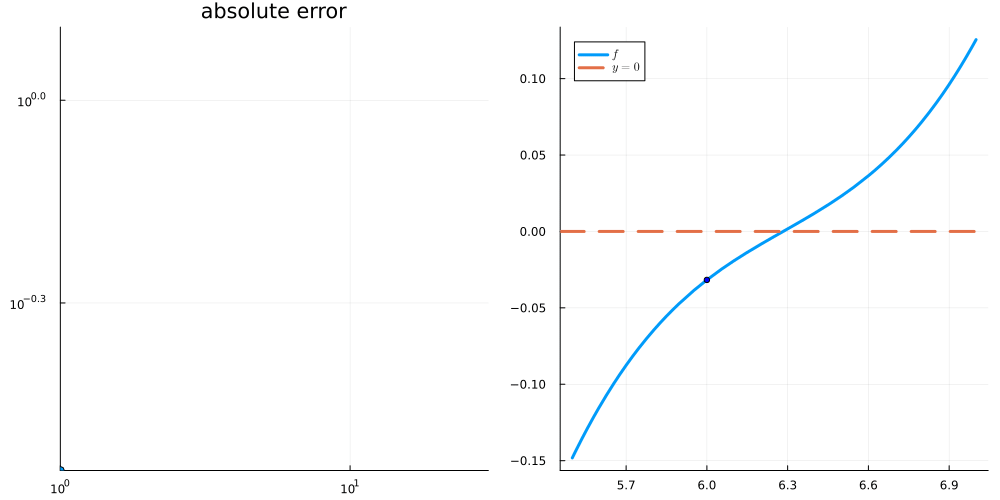

In [5]:
λ = 1;
x = relaxation( f, λ, 6.; N=30);

anim = @animate for n ∈ 1:length(x)
    err = abs.( x[1:n] .- ξ )
    plt1 = plot( err , 
        xlims=(1, length(x)), 
        ylims=(minimum(err), maximum(err)),
        yaxis=:log, xaxis=:log, m=:o, lw=3, 
        title="absolute error", legend=false )
    plt2 = plot( f, 5.5, 7, label=L"f", lw=3 )
    scatter!( [x[1:n]], [f.(x[1:n])], 
        primary=false, marker=3, color="blue")
    hline!( [0] , linestyle=:dash, lw = 3, label=L"y=0")

    plot( plt1, plt2, size=(1000,500) )
end
gif(anim, "../images/Relaxed.gif", fps = 1)

* Play around with $\lambda$, how does this affect the plot on the right?

::: {#thm-relaxation}
# Convergence: Relaxation

Suppose that $f: [a,b]\to\mathbb R$ is continuously differentiable with $f(\xi) = 0$, $f'(\xi) \not= 0$. Then, there exists $\delta, \lambda> 0$ such that $x_{n+1} = x_n - \lambda f(x_n)$ converges at least linearly to $\xi$ for all $x_1 \in I_\delta := [\xi-\delta,\xi+\delta]$. The asymptotic error constant (for $\alpha =1$) is given by $\left| 1 - \lambda f'(\xi) \right|$.

:::

::: {#exm-Kepler-2}
# Kepler's cont.

We have,

\begin{align*}
    &f(\psi) = \psi - \epsilon \sin \psi - 2\pi \qquad &f(2\pi) = 0 \nonumber\\
    &f'(\psi) = 1 - \epsilon \cos \psi \qquad &f'(2\pi) = 1 - \epsilon. \nonumber\\
\end{align*}

Therefore, for $\epsilon \not= 1$, we have $f(2\pi) = 0 \not= f'(2\pi)$ and so we can apply @thm-relaxation. Relaxation converges linearly with asymptotic error constant $\mu := \left| 1 - \lambda f'(2\pi) \right| = \left| 1 - \lambda (1-\epsilon) \right|$. 

In the above example, we chose $\epsilon = 0.9$ and so the asymptotic error constant is $\left| 1 - 0.1\lambda \right|$. This is in good agreement with what we see numerically:

:::

In [6]:
orderOfConvergence( x, 2π; α=1 )

iteration  abs error        log error    α          μ (α=1.0)     
1          2.831853e-01     -0.5479      NaN        NaN           
2          2.514739e-01     -0.5995      1.0941     0.8880        
3          2.239486e-01     -0.6499      1.0840     0.8905        
4          1.998732e-01     -0.6992      1.0760     0.8925        
5          1.786906e-01     -0.7479      1.0696     0.8940        
6          1.599670e-01     -0.7960      1.0643     0.8952        
7          1.433571e-01     -0.8436      1.0598     0.8962        
8          1.285799e-01     -0.8908      1.0560     0.8969        
9          1.154033e-01     -0.9378      1.0527     0.8975        
10         1.036326e-01     -0.9845      1.0498     0.8980        
11         9.310249e-02     -1.0310      1.0473     0.8984        
12         8.367124e-02     -1.0774      1.0450     0.8987        
13         7.521628e-02     -1.1237      1.0429     0.8990        
14         6.763084e-02     -1.1699      1.0411     0.8992    

In [7]:
println( "f'(ξ) = ", f′(ξ))
println( "Theoretical asymptotic error constant μ = 1 - λf'(ξ) = ", 1 - λ*f′(ξ) )

f'(ξ) = 0.09999999999999998
Theoretical asymptotic error constant μ = 1 - λf'(ξ) = 0.9


**Proof.** Relaxation is a simple iteration with $g(x) = x - \lambda f(x)$. We wish to apply the contraction mapping theorem and thus it is sufficient to check $|g'(\xi)| \leq L < 1$.

Suppose that $f'(\xi) > 0$ (the proof is very similar in the other case). Since $f'$ is continuous, there exists $\delta> 0$ such that 

\begin{align*}
   m := \frac12 f'(\xi) \leq f'(x) \leq M := \max_{y\in [a,b]} f'(y).
\end{align*}

As a result, we have $1 - \lambda M \leq 1 - \lambda f'(x) \leq 1 - \lambda m$. Choosing $L = 1 - \lambda m = \lambda M - 1$ gives $\lambda = \frac{2}{M+m}$ and thus 

\begin{align*}
    L = 1 - \frac{2m}{m + M} = \frac{M-m}{M+m} < 1.
\end{align*}

## Newton

* $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_{n})}$

In [8]:
function Newton( f, f_prime, x1; N=100, tol=1e-10)
    x = [x1]
    for n ∈ 2:N
        push!( x, x[n-1] - f(x[n-1])/f_prime(x[n-1]) )
        r = abs(f(x[end]));
        if (r < tol)
            return x
        end
    end
    @warn "max interations |f| = $r";
    return x
end

Newton (generic function with 1 method)

[ Info: Saved animation to c:\Users\jack6\Math5485-Fall-2026\Math5485\images\Newton.gif


Plots.AnimatedGif("c:\\Users\\jack6\\Math5485-Fall-2026\\Math5485\\images\\Newton.gif")
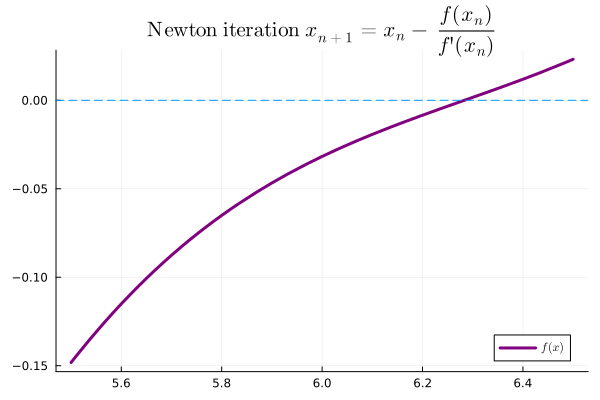

In [9]:
y = Newton( f, f′, 5.5; tol=1e-7);

plot( f , 5.5, 6.5, # ,1.5, #-.25, 2, 
    label=L"f(x)", lw=3, title=L"\textrm{Newton~iteration~} x_{n+1} = x_n - \frac{f(x_{n})}{f'(x_n)}",
    color="purple", linestyle=:solid)
hline!([0], linestyle=:dash, primary=false)

anim = @animate for n ∈ 1:2(length(y)-1)
    if (n==1)
        
    elseif (n%2 == 0)
        k = Int(n/2)
        plot!( [y[k], y[k]], [0, f(y[k])], 
            primary=false, lw=2, color="blue")
    else
        k = Int((n+1)/2)
        plot!( [y[k-1], y[k]], [f(y[k-1]), 0], 
            primary=false, lw=2, color="blue")
    end
end
gif(anim, "../images/Newton.gif", fps = 1)

::: {#thm-Newton}
# Convergence: Newton 

Suppose $f: [a,b] \to \mathbb R$ is twice continuously differentiable with $f(\xi) = 0$ and $f'(\xi) \not= 0$ for some $\xi \in [a,b]$. Further suppose that 

\begin{align}
    \left|\frac{f''(x)}{f'(y)}\right| \leq A
\end{align}

for all $x,y \in [a,b]$. Then, the Newton iteration $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$ converges at least quadratically to $\xi$ for all $x_1 \in [a,b]$ such that $|x_1 - \xi| \leq A^{-1}$. The asymptotic error constant $\mu$ is $\frac12 \left|\frac{f''(\xi)}{f'(\xi)}\right|$.

:::


::: {#exr-2025-A2-cont}

[](../exercises/bank.html#bank-exr-2025-A2-cont)

@exr-2025-A2 continued...

This is an example of Newton's method!

\begin{align}
    x_{n+1} = \frac12 \left( x_n + \frac{a}{x_n} \right)
\end{align}

is the Newton iteration with $f(x) = x^2 - a$. Notice that $\xi = \sqrt{a}$ and $f'(\xi) = 2\sqrt{a}$, $f''(\xi) = 2$. 

Compute the order of convergence and asymptotic error constant numerically, and compare to @thm-Newton.

:::

In [10]:
g(x) = x^2 - 2
g′(x) = 2*x 
orderOfConvergence( Newton(g,g′,1.), sqrt(2); α=2 )

println( "theoretical value of μ (for α=2) = ",  (1/2) * ( 2/ g′(sqrt(2)) ) )

iteration  abs error        log error    α          μ (α=2.0)     
1          4.142136e-01     -0.3828      NaN        NaN           
2          8.578644e-02     -1.0666      2.7864     0.5000        
3          2.453104e-03     -2.6103      2.4473     0.3333        
4          2.123901e-06     -5.6729      2.1733     0.3529        
5          1.594724e-12     -11.7973     2.0796     0.3535        
theoretical value of μ (for α=2) = 0.35355339059327373


**Proof.** First, notice that $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_{n})}$ and so 

\begin{align}
    -f(x_n) &= f'(x_{n}) (x_{n+1} - x_{n}) \nonumber\\
        &= f'(x_{n}) (\xi - x_n) + f'(x_{n}) (x_{n+1} - \xi). 
\end{align}

At the same time, there exists $\eta_n$ between $x_n$ and $\xi$ such that 

\begin{align}
    0 = f(\xi) 
    &= f(x_n) + f'(x_n) ( \xi - x_{n} ) + \frac{1}{2} f''(\eta_n) (x_n - \xi)^2 \nonumber\\
    &= f(x_n) + \big[ -f(x_n) - f'(x_{n}) (x_{n+1} - \xi) \big] + \frac{1}{2} f''(\eta_n) (x_n - \xi)^2.
\end{align}

Therefore, assuming $x_n \in [a,b]$, we obtain 

\begin{align}
    \left| x_{n+1} - \xi \right| &= \frac{1}{2} \left| \frac{f''(\eta_n)}{f'(x_n)} \right| (x_n - \xi)^2 \nonumber\\
        %
        &\leq \frac12 A |x_n - \xi|^2.
\end{align}

If $|x_1 - \xi| \leq A^{-1}$ then, we have $|x_2 - \xi| \leq A |x_1 - \xi|^2 \leq A A^{-1} |x_1 - \xi| \leq A^{-1}$. Proceeding iteratively, we obtain $|x_{n} - \xi| \leq A^{-1}$. As a result, we have $\left| x_{n+1} - \xi \right| \leq \frac12 |x_n - \xi|$ and so $(x_n) \to \xi$. Finally, we have 

\begin{align}
    \frac{\left| x_{n+1} - \xi \right|}{|x_n - \xi|^2} = \frac{1}{2} \left| \frac{f''(\eta_n)}{f'(x_n)} \right| \to \frac12 \left| \frac{f''(\xi)}{f'(\xi)} \right|
\end{align}

as $n\to\infty$.

::: {#exm-Kepler-3}
# Kepler cont.

Recall that

\begin{align*}
    &f(\psi) = \psi - \epsilon \sin \psi - 2\pi \qquad &f(2\pi) = 0 \nonumber\\
    &f'(\psi) = 1 - \epsilon \cos \psi \qquad &f'(2\pi) = 1 - \epsilon \nonumber\\
    &f''(\psi) = \epsilon \sin \psi \qquad &f''(2\pi) = 0 \nonumber\\
    &f'''(\psi) = \epsilon \cos \psi \qquad &f'''(2\pi) = \epsilon.
\end{align*}

Therefore, for $\epsilon \not= 1$, we can apply the above theorem. Newton therefore converges at least quadratically with asymptotic error constant $\mu = \frac12 \left| \frac{f''(2\pi )}{f'(2\pi)} \right| = 0$. As a result, we would expect Newton iteration to converge super-quadratically in this case:

In [11]:
orderOfConvergence( y, 2π ; α = 2)

iteration  abs error        log error    α          μ (α=2.0)     
1          7.831853e-01     -0.1061      NaN        NaN           
2          3.740187e-01     -0.4271      4.0242     0.6098        
3          9.541332e-02     -1.0204      2.3891     0.6821        
4          2.501088e-03     -2.6019      2.5499     0.2747        
5          4.693489e-08     -7.3285      2.8166     0.0075        


In fact, in this case the convergence is cubic with asymptotic error constant $\mu = \frac13 \left| \frac{f'''(\xi)}{f'(\xi)} \right| = \frac13 \frac{\epsilon}{1-\epsilon}$ (**Exercise**: why?). 

:::

In [12]:
println( "theoretical value of μ (for α=3) = ",  (1/3) * ( ϵ/ (1-ϵ) ) ) 

theoretical value of μ (for α=3) = 3.0000000000000004


::: {#exr-2025-A5-B}

[](../exercises/bank.html#bank-exr-2025-A5-B)

TODO: add *Assignment 5, Fall 2025, Section B* to the exercises

What happens when applying Newton to Kepler's equation with $\epsilon = 1$ (in this case $f(2\pi) = f'(2\pi) = f''(2\pi) = 0$).
 
:::


## Secant Method

* Consider $x_{n+1} = g(x_n, x_{n-1})$ 
* Consider Newton but with an approximate derivative: 

\begin{align}
    f'(x_n) &\approx \frac{f(x_{n}) - f(x_{n-1})}{x_{n} - x_{n-1}}
    \nonumber\\ &= f[x_n, x_{n-1}] 
\end{align}

* That is, $x_{n+1} = x_n - \frac{f(x_n)}{f[x_n, x_{n-1}]}$

[ Info: Saved animation to c:\Users\jack6\Math5485-Fall-2026\Math5485\images\Secant.gif


Plots.AnimatedGif("c:\\Users\\jack6\\Math5485-Fall-2026\\Math5485\\images\\Secant.gif")
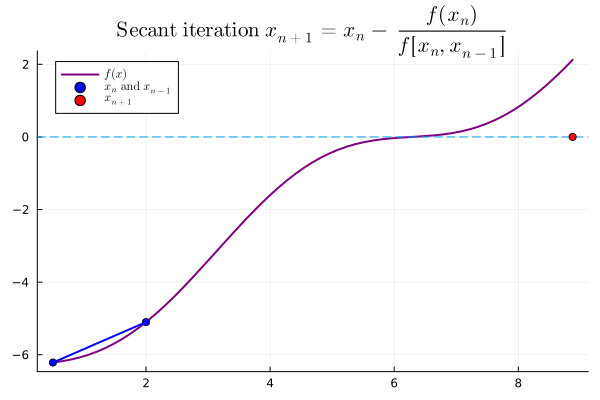

In [14]:
function secant( f, x1, x2; N=100, tol=1e-8)
    x = [x1, x2];
    for n in 3:N 
       push!(x, x[n-1] - ((x[n-1] - x[n-2])/(f(x[n-1]) - f(x[n-2]))) * f(x[n-1]) )
       if (abs(f(x[end])) < tol)
            break
        end
    end
    return x
end

z = secant( f, 0.5, 2.0 ,N=20)

anim = @animate for n ∈ 3:length(z)
    plot( f , minimum(z), maximum(z), # ,1.5, #-.25, 2, 
    label=L"f(x)", title=L"\textrm{Secant~iteration~} x_{n+1} = x_n - \frac{f(x_n)}{f[x_n,x_{n-1}]}",
    color="purple", linestyle=:solid, lw=2)
hline!([0], linestyle=:dash, primary=false)

    scatter!( [z[n-2], z[n-1]], [f(z[n-2]), f(z[n-1])], color="blue", label=L"x_{n} \textrm{~and~} x_{n-1}" )
    plot!( [z[n-2], z[n-1]], [f(z[n-2]), f(z[n-1])], 
            primary=false, lw=2, color="blue")
    scatter!( [z[n]], [0], color="red", label=L"x_{n+1}")
end
gif(anim, "../images/Secant.gif", fps = 1)

::: {#thm-Secant}
# Convergence: Secant

Suppose $f: [a,b] \to \mathbb R$ is continuously differentiable with $f(\xi) = 0$ and $f'(\xi) \not= 0$ for some $\xi \in [a,b]$. Then, the Secant iteration $x_{n+1} = x_n - \frac{f(x_n)}{f[x_n,x_{n-1}]}$ converges at least linearly to $\xi$ for all $x_1,x_2$ sufficiently close to $\xi$. 

:::

::: {#rem-ooc-Secant}

In fact, order of convergence $\alpha = \frac{1 + \sqrt{5}}{2}$ in this case, with $\mu =  \left| \frac{f''(\xi)}{2 f'(\xi)} \right|^{\alpha/(1 + \alpha)}$. 

:::


::: {#exm-sqrt-2}

Let's try and approximate $\sqrt{2}$ again:

In [15]:
# g(x) = x^2 - 2 is already defined 

a = (1/2)*(1 + sqrt(5));
mu = ( 2/(2*2*sqrt(2)) )^(a/(1+a));

orderOfConvergence( secant( g, 1. ,2. ), sqrt(2); α=a )
println("theoretical values of (α, μ) = (", a, ", " , mu, ")" )

iteration  abs error        log error    α          μ (α=1.62)    
1          4.142136e-01     -0.3828      NaN        NaN           
2          5.857864e-01     -0.2323      0.6068     2.4383        
3          8.088023e-02     -1.0922      4.7023     0.1922        
4          1.421356e-02     -1.8473      1.6914     0.8315        
5          4.205840e-04     -3.3761      1.8276     0.4101        
6          2.123898e-06     -5.6729      1.6803     0.6164        
7          3.157747e-10     -9.5006      1.6747     0.4767        
theoretical values of (α, μ) = (1.618033988749895, 0.5259323034521867)


:::

**Proof.** Again, we may apply Taylor's remainder theorem: there exists $\eta_n$ between $x_n$ and $x_{n-1}$ such that $f[x_n, x_{n-1}] = f'(\eta_n)$ and $\theta_n$ between $x_n$ and $\xi$ such that $f(x_n) = f'(\xi)(x_n - \xi)$. As a result, we have  

\begin{align}
    x_{n+1} - \xi &= x_n - \xi - \frac{f(x_n)}{ f[x_n, x_{n-1}] } \nonumber\\
    %
    &= \left( 1 - \frac{f'(\theta_n)}{ f'(\eta_n) } \right) (x_n - \xi) 
\end{align}

If $f'(\xi) > 0$, then there exists a closed interval $I = [\xi-\delta, \xi+\delta]$ such that 

\begin{align*}
    0 < \frac34 f'(\xi) < f'(x) < \frac54 f'(\xi)
\end{align*}

for all $x \in I$. If $x_n, x_{n-1} \in I$ then $\eta_n, \theta_n \in I$ and so we have $\frac23 < 1 - \frac{f'(\theta_n)}{ f'(\eta_n) } < \frac25$ and thus $x_{n+1} \in I$ with 

\begin{align}
    |x_{n+1} - \xi| \leq \frac23 |x_{n}-\xi| \leq \cdots \leq \left(\frac23\right)^n |x_1 - \xi|.
\end{align}

That is, the sequence converges at least linearly. Moreover, by (1), we have $|x_{n+1}-\xi|/|x_n - \xi| \to 0$ as $n\to\infty$.

::: {#def-efficiency}
# Efficiency index 

The efficiency index is $E := \alpha^{1/\theta}$ where $\theta$ is the number of function evaluations at each step of the iteration. This measures the order of the method *per function evaluation*

:::


::: {.callout-note}

Newton when $f'(\xi), f''(\xi) \not= 0$, we have $E = 2^{1/2} \approx 1.41...$ since the order of convergence is $2$ and we need to evaluate $f$ and $f'$ at $x_n$.

Secant when $f'(\xi) \not= 0$, we have $E = \left[\frac12\big( 1 + \sqrt{5} \big)\right]^{1/1} \approx 1.618...$ since the order of convergence is $\frac12\big( 1 + \sqrt{5} \big)$ and we only require one function evaluation per iteration.

 
:::


:::{.callout-tip}
# TO-DO

* Assignment 2: Due in a week!
* Exercises throughout the notes,
* (Sign-up to office hours if you like)

:::

## Extra exercises

::: {#exr-faster-linear title="Faster than linear convergence"} 

[](../exercises/bank.html#bank-exr-faster-linear)

Suppose that $g$ is twice continuously differentiable with $g(\xi) = \xi$ and $g'(\xi) = 0$.

1. ✍️ Show that there exists $\delta > 0$ such that $x_{n+1} = g(x_n)$ converges to $\xi$ for all $x_1 \in [\xi - \delta, \xi + \delta]$.  
2. ✍️ Show that 

\begin{align}
    \lim_{n\to\infty} \frac{|x_{n+1} - \xi|}{|x_n - \xi|^2} = \frac12 |g''(\xi)| \nonumber
\end{align}

(whenever $x_n \not= \xi$ for all $n$). What is the order of convergence when $g''(\xi) \not= 0$?  

::: 

::: {#exr-Newton-1 title="Newton"}

[](../exercises/bank.html#bank-exr-Newton-1)

*Newton's method* $x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$ is the simple iteration with $g(x) := x - \frac{f(x)}{f'(x)}$.

✍️ Suppose that $f$ is three times continuously differentiable with $f(\xi) = 0$ and $f'(\xi) \not= 0$. Show that $g'(\xi) = 0$ and $g''(\xi) = \frac{f''(\xi)}{f'(\xi)}$. What does this tell you about Newton's method?

::: {.exercise-hint style="display: none;"}
Taylor's theorem.
:::

:::

::: {#exr-division-iter title="Division without dividing"}

[](../exercises/bank.html#bank-exr-division-iter)

Fix $a > 0$.

1. ✍️ Show that Newton's method applied to $f(x) := \frac1x - a$ is given by $x_{n+1} = x_n(2 - a x_n)$.  
2. ✍️ Define $e_n := 1 - a x_n$ and show that $e_{n+1} = e_n^2$. Hence, find all $x_1$ for which $(x_n) \to \frac1a$.  
3. ✍️ Show that $\left| x_{n+1} - \frac1a \right| = a \left| x_n - \frac1a \right|^2$. What are the order of convergence and the asymptotic error constant? Compare with the asymptotic error constant $\mu = \frac12 \left| \frac{f''(\xi)}{f'(\xi)} \right|$ from lectures.  
4. 💻 Take $a = 7$. Verify your answers to (ii) and (iii) numerically using $x_1 = 0.1, 0.28$, and $0.3$.

:::